Potential Analyses

- Target variable over time
- Distributional analysis of subset(s) to overall sample
- Generative distribution (reconstruct "story" based on underlying statistical properties)


In [1]:
import polars as pl
import seaborn as sns
import numpy as np

In [2]:
DATA_FOLDER = "../data/processed"
lf = pl.scan_parquet(f"{DATA_FOLDER}/index_data.parquet")

In [3]:
lf.collect_schema().names()

['unique_id',
 'sex',
 'race',
 'age',
 'highest_educational_level',
 'low_income_status',
 'employment_status',
 'occupational_code_pre',
 'industry_code_q1_pre',
 'industry_code_q2_pre',
 'industry_code_q3_pre',
 'wages_3q_pre',
 'wages_2q_pre',
 'wages_1q_pre',
 'occupational_code_post',
 'industry_code_q1_post',
 'industry_code_q2_post',
 'industry_code_q3_post',
 'industry_code_q4_post',
 'wages_1q_post',
 'wages_2q_post',
 'wages_3q_post',
 'wages_4q_post',
 'workforce_board_code_1',
 'workforce_board_code_2',
 'workforce_board_code_3',
 'state',
 'is_adult',
 'is_dislocated_worker',
 'is_youth',
 'is_wagner_peyser',
 'is_reportable_individual',
 'received_training',
 'entry_date',
 'exit_date',
 'entry_year',
 'entry_quarter',
 'exit_year',
 'exit_quarter',
 'industry_code_pre',
 'industry_code_post',
 'funding_stream',
 'subsector_code_pre',
 'subsector_code_post',
 '',
 'occupation_title_pre',
 'r_cog_pre',
 'r_man_pre',
 'offshor_pre',
 '_right',
 'occupation_title_post',
 'r

In [4]:
n_rows = lf.select(pl.len()).collect().item()
print("Number of rows: ", n_rows)

Number of rows:  12726789


In [5]:
df = lf.collect()

In [6]:
df_sample = df.sample(fraction=0.01, with_replacement=False)
n_rows_sample = df_sample.select(pl.len()).item()
print("Number of rows in sample: ", n_rows_sample)

Number of rows in sample:  127267


In [7]:
df_sample = df_sample.to_pandas()

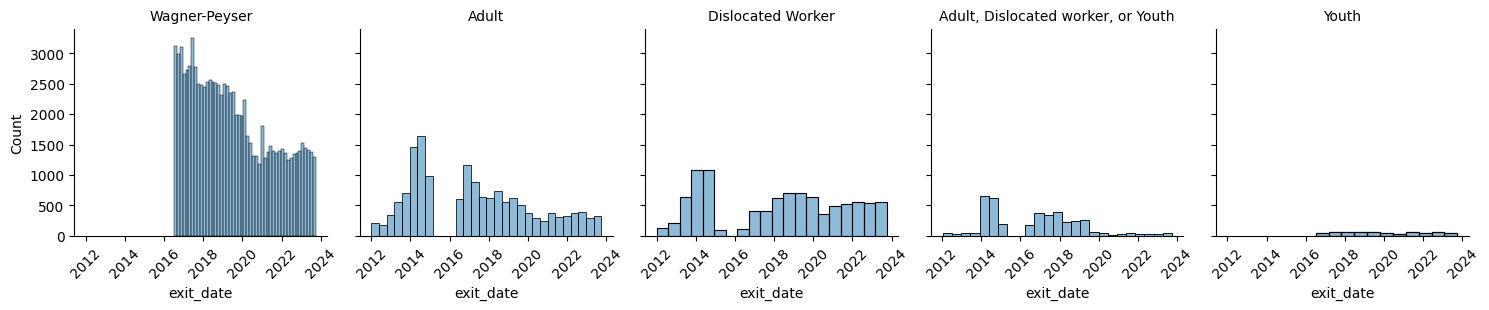

In [8]:
g = sns.FacetGrid(df_sample, col="funding_stream", despine=True)

g.map_dataframe(sns.histplot, x="exit_date", hue="funding_stream")

g.set_titles(col_template="{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

g.figure.show()

In [35]:
import matplotlib.pyplot as plt

In [45]:
df_sample.columns

Index(['unique_id', 'sex', 'race', 'age', 'highest_educational_level',
       'low_income_status', 'employment_status', 'occupational_code_pre',
       'industry_code_q1_pre', 'industry_code_q2_pre', 'industry_code_q3_pre',
       'wages_3q_pre', 'wages_2q_pre', 'wages_1q_pre',
       'occupational_code_post', 'industry_code_q1_post',
       'industry_code_q2_post', 'industry_code_q3_post',
       'industry_code_q4_post', 'wages_1q_post', 'wages_2q_post',
       'wages_3q_post', 'wages_4q_post', 'workforce_board_code_1',
       'workforce_board_code_2', 'workforce_board_code_3', 'state', 'is_adult',
       'is_dislocated_worker', 'is_youth', 'is_wagner_peyser',
       'is_reportable_individual', 'received_training', 'entry_date',
       'exit_date', 'entry_year', 'entry_quarter', 'exit_year', 'exit_quarter',
       'industry_code_pre', 'industry_code_post', 'funding_stream',
       'subsector_code_pre', 'subsector_code_post', '', 'occupation_title_pre',
       'r_cog_pre', 'r_man_pre',

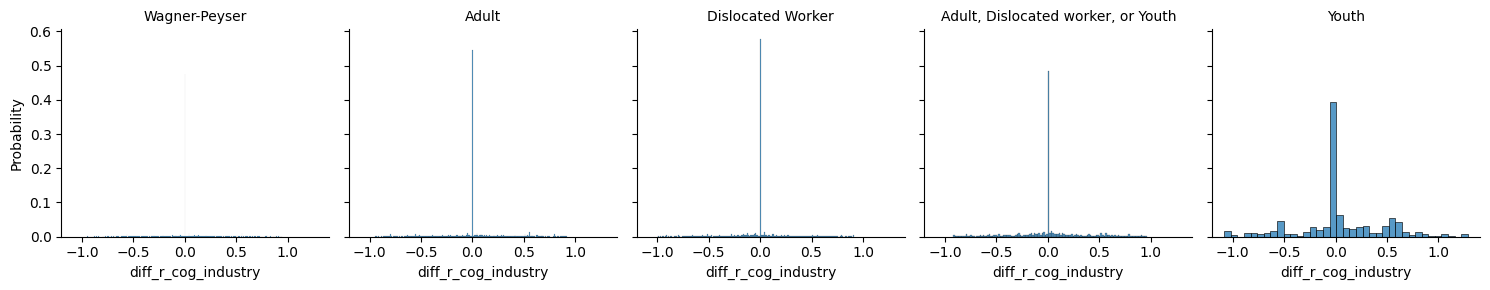

In [73]:
metric = "diff_r_cog_industry"

q_low = df_sample.groupby("funding_stream")[metric].transform(lambda x: x.quantile(0.01))
q_high = df_sample.groupby("funding_stream")[metric].transform(lambda x: x.quantile(0.99))

df_filtered = df_sample[(df_sample[metric] >= q_low) & (df_sample[metric] <= q_high)]

g = sns.FacetGrid(df_filtered, col="funding_stream", despine=True)

g.map_dataframe(sns.histplot, x=metric, stat="probability")

# for ax in g.axes.flatten():
#     ax.set_xlim(-100000, 100000)

g.set_titles(col_template="{col_name}")

g.figure.show()